## Data CLenaing And EDA

In [9]:
# Data Cleaning and EDA of customer file

In [28]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


## Customer Data

In [119]:
# read the file
customers = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Retails Analytics/customers.csv')
customers

,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18.0,11-07-2025,South
1,C0001,Eric,Lee,Other,36.0,20-09-2021,East
2,C0002,Thomas,Pena,Female,NaN,07-03-2022,East
3,C0003,Dalton,Duran,Male,24.0,29-08-2022,South
4,C0004,Travis,Mcclain,Male,50.0,29-03-2024,South
...,...,...,...,...,...,...,...
811,C0476,John,Le,Female,29.0,23-11-2023,West
812,C0059,Alison,Berger,Male,56.0,16-11-2021,West
813,C0600,Timothy,Cunningham,Male,39.0,24-04-2022,South
814,C0480,Matthew,Moore,Female,27.0,23-05-2021,South


In [10]:
#count not null values and data types
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  816 non-null    object 
 1   first_name   816 non-null    object 
 2   last_name    816 non-null    object 
 3   gender       816 non-null    object 
 4   age          776 non-null    float64
 5   signup_date  816 non-null    object 
 6   region       816 non-null    object 
dtypes: float64(1), object(6)
memory usage: 44.8+ KB


In [11]:
#statistical information
customers.describe()

,age
count,776.000000
mean,44.074742
std,15.316349
min,18.000000
25%,31.000000
50%,44.000000
75%,58.000000
max,70.000000


In [12]:
customers.shape

(816, 7)

In [13]:
customers.isnull().sum()

customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

In [14]:
# fill missing values
customers['age'] = customers['age'].fillna(customers['age'].median())

In [15]:
customers.duplicated().sum()

np.int64(16)

In [16]:
# drop duplicates
customers = customers.drop_duplicates()

In [17]:
print(customers.isnull().sum())

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
dtype: int64


In [18]:
customers.duplicated().sum()

np.int64(0)

In [19]:
# change the datatype of age column
customers['age'] = customers['age'].astype(int)

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_12726/1227768065.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customers['age'] = customers['age'].astype(int)


In [20]:
# change data of signup_date column
customers['signup_date'] = pd.to_datetime(customers['signup_date'],format='%d-%m-%Y',errors='coerce')

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_12726/437151476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customers['signup_date'] = pd.to_datetime(customers['signup_date'],format='%d-%m-%Y',errors='coerce')


In [21]:
#datatype of fields
customers.dtypes

customer_id            object
first_name             object
last_name              object
gender                 object
age                     int64
signup_date    datetime64[ns]
region                 object
dtype: object

In [22]:
# create a age group column 
customers["age_group"] = pd.cut(customers["age"],bins=[0,25,40,60,100],
                                labels=["18-25","26-40","41-60","60+"]
                               )

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_12726/1007929978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customers["age_group"] = pd.cut(customers["age"],bins=[0,25,40,60,100],


In [23]:
customers

,customer_id,first_name,last_name,gender,age,signup_date,region,age_group
0,C0000,Patrick,Morgan,Male,18,2025-07-11,South,18-25
1,C0001,Eric,Lee,Other,36,2021-09-20,East,26-40
2,C0002,Thomas,Pena,Female,44,2022-03-07,East,41-60
3,C0003,Dalton,Duran,Male,24,2022-08-29,South,18-25
4,C0004,Travis,Mcclain,Male,50,2024-03-29,South,41-60
...,...,...,...,...,...,...,...,...
795,C0795,Emily,Smith,Male,42,2025-04-03,South,41-60
796,C0796,Jonathan,Gardner,Other,20,2024-03-08,South,18-25
797,C0797,Jordan,Smith,Other,56,2021-04-29,West,41-60
798,C0798,Rachel,Porter,Other,39,2021-08-12,South,26-40


In [24]:
# save the file
customers.to_csv("customers_cleaned.csv", index=False)

## Sales Data

In [2]:
# read the file
salesdata = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Retails Analytics/salesdata.csv')
salesdata

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
0,O00000,31-01-2025,C0125,P1086,NaN,Online,2,80.63,0.05,153.20
1,O00001,29-09-2025,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00
2,O00002,29-08-2024,C0653,P0659,NaN,Online,2,218.60,0.10,393.48
3,O00003,13-05-2025,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82
4,O00004,22-07-2025,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94
...,...,...,...,...,...,...,...,...,...,...
3055,O02044,26-09-2025,C0580,P0886,S024,In-Store,2,82.92,0.00,165.84
3056,O02352,16-11-2024,C0632,P0091,S034,In-Store,1,27.29,0.10,24.56
3057,O02014,25-06-2024,C0127,P0296,NaN,Online,3,34.89,0.00,104.67
3058,O01371,12-02-2025,C0741,P1056,NaN,Online,1,57.51,0.05,54.63


In [4]:
# Counts non null value and data type 
salesdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3060 non-null   object 
 1   order_date     3060 non-null   object 
 2   customer_id    3060 non-null   object 
 3   product_id     3060 non-null   object 
 4   store_id       2068 non-null   object 
 5   sales_channel  3060 non-null   object 
 6   quantity       3060 non-null   int64  
 7   unit_price     3060 non-null   float64
 8   discount_pct   3060 non-null   float64
 9   total_amount   3060 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 239.2+ KB


In [5]:
salesdata.describe()

,quantity,unit_price,discount_pct,total_amount
count,3060.000000,3060.000000,3060.000000,3060.000000
mean,1.816340,160.494961,0.088056,272.423582
std,1.749869,91.106112,0.074714,411.177912
min,1.000000,6.770000,0.000000,6.970000
25%,1.000000,83.700000,0.050000,107.467500
50%,2.000000,161.170000,0.050000,196.580000
75%,2.000000,229.100000,0.200000,337.460000
max,30.000000,382.320000,0.200000,8855.800000


In [6]:
salesdata.shape

(3060, 10)

In [7]:
salesdata.isnull().sum()

order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64

In [8]:
# fill missing values
salesdata['store_id'] = salesdata['store_id'].fillna('ONLINE_STORE')
salesdata['sales_channel'] = salesdata['sales_channel'].replace('Online','Online')

In [9]:
salesdata.isnull().sum()

order_id         0
order_date       0
customer_id      0
product_id       0
store_id         0
sales_channel    0
quantity         0
unit_price       0
discount_pct     0
total_amount     0
dtype: int64

In [10]:
salesdata.duplicated().sum()

np.int64(60)

In [11]:
# drop duplicates
salesdata = salesdata.drop_duplicates()
salesdata.duplicated().sum()

np.int64(0)

In [12]:
#Datatypes of field
salesdata.dtypes

order_id          object
order_date        object
customer_id       object
product_id        object
store_id          object
sales_channel     object
quantity           int64
unit_price       float64
discount_pct     float64
total_amount     float64
dtype: object

In [13]:
salesdata['order_date'] = pd.to_datetime(salesdata['order_date'], errors='coerce')

salesdata['quantity'] = pd.to_numeric(salesdata['quantity'], errors='coerce')
salesdata['unit_price'] = pd.to_numeric(salesdata['unit_price'], errors='coerce')
salesdata['discount_pct'] = pd.to_numeric(salesdata['discount_pct'], errors='coerce')
salesdata['total_amount'] = pd.to_numeric(salesdata['total_amount'], errors='coerce')

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/2860446359.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  salesdata['order_date'] = pd.to_datetime(salesdata['order_date'], errors='coerce')
/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/2860446359.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salesdata['order_date'] = pd.to_datetime(salesdata['order_date'], errors='coerce')
/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/2860446359.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [14]:
salesdata.dtypes

order_id                 object
order_date       datetime64[ns]
customer_id              object
product_id               object
store_id                 object
sales_channel            object
quantity                  int64
unit_price              float64
discount_pct            float64
total_amount            float64
dtype: object

In [15]:
#feature engineering
# Gross Revenue
salesdata['gross_revenue'] = salesdata['unit_price'] * salesdata['quantity']

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/2158556931.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salesdata['gross_revenue'] = salesdata['unit_price'] * salesdata['quantity']


In [16]:
# effective selling price
salesdata['effective_price'] = salesdata['total_amount'] / salesdata['quantity']

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/681052885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salesdata['effective_price'] = salesdata['total_amount'] / salesdata['quantity']


In [17]:
#discount amount
salesdata['discount_amount'] = salesdata['gross_revenue'] - salesdata['total_amount']

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/3036814602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salesdata['discount_amount'] = salesdata['gross_revenue'] - salesdata['total_amount']


In [18]:
salesdata = salesdata.merge(products[["product_id", "cost_price"]],on="product_id",how="left")

#Profit = (Selling Price × Quantity − Discount) − (Cost Price × Quantity)
salesdata["profit"] = (salesdata["total_amount"] -(salesdata["cost_price"] * salesdata["quantity"]))

In [19]:
salesdata

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount,gross_revenue,effective_price,discount_amount,cost_price,profit
0,O00000,2025-01-31,C0125,P1086,ONLINE_STORE,Online,2,80.63,0.05,153.20,161.26,76.60,8.06,69.87,13.46
1,O00001,2025-09-29,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00,4183.20,198.70,209.20,120.11,1571.80
2,O00002,2024-08-29,C0653,P0659,ONLINE_STORE,Online,2,218.60,0.10,393.48,437.20,196.74,43.72,173.17,47.14
3,O00003,2025-05-13,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82,78.53,62.82,15.71,65.86,-3.04
4,O00004,2025-07-22,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94,344.93,275.94,68.99,174.83,101.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3117,O02995,2025-03-09,C0346,P0972,ONLINE_STORE,Online,1,113.58,0.20,90.86,113.58,90.86,22.72,81.65,9.21
3118,O02996,2025-11-10,C0714,P0856,S047,In-Store,1,72.18,0.05,68.57,72.18,68.57,3.61,53.24,15.33
3119,O02997,2025-08-18,C0217,P0586,S021,In-Store,3,276.20,0.20,662.88,828.60,220.96,165.72,192.31,85.95
3120,O02998,2024-11-11,C0591,P0053,S006,In-Store,1,222.76,0.20,178.21,222.76,178.21,44.55,186.69,-8.48


In [20]:
salesdata.isnull().sum()

order_id           0
order_date         5
customer_id        0
product_id         0
store_id           0
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
gross_revenue      0
effective_price    0
discount_amount    0
cost_price         0
profit             0
dtype: int64

In [22]:
salesdata['order_date'] = salesdata['order_date'].fillna(method='ffill')

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_29343/71333427.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  salesdata['order_date'] = salesdata['order_date'].fillna(method='ffill')


In [23]:
salesdata.isnull().sum()

order_id           0
order_date         0
customer_id        0
product_id         0
store_id           0
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
gross_revenue      0
effective_price    0
discount_amount    0
cost_price         0
profit             0
dtype: int64

In [24]:
salesdata.duplicated().sum()

np.int64(122)

In [25]:
salesdata = salesdata.drop_duplicates()
salesdata.duplicated().sum()

np.int64(0)

In [26]:
# save the file
salesdata.to_csv("salesdata_cleaned.csv", index=False)

In [27]:
salesdata.isnull().sum()

order_id           0
order_date         0
customer_id        0
product_id         0
store_id           0
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
gross_revenue      0
effective_price    0
discount_amount    0
cost_price         0
profit             0
dtype: int64

## Products Data

In [3]:
# read the file
products = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Retails Analytics/products.csv')
products

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35
...,...,...,...,...,...,...,...
1219,P0998,BrandB Stuff,Personal Care,BrandD,13.87,19.62,29.31
1220,P0684,BrandA Hear,Home & Kitchen,BrandC,161.31,222.84,27.61
1221,P0498,BrandD South,Personal Care,BrandD,19.73,35.81,44.90
1222,P1016,BrandA Watch,Electronics,BrandC,186.81,321.00,41.80


In [188]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1224 non-null   object 
 1   product_name  1224 non-null   object 
 2   category      1224 non-null   object 
 3   brand         1164 non-null   object 
 4   cost_price    1224 non-null   float64
 5   unit_price    1224 non-null   float64
 6   margin_pct    1224 non-null   float64
dtypes: float64(3), object(4)
memory usage: 67.1+ KB


In [189]:
products.describe()

,cost_price,unit_price,margin_pct
count,1224.000000,1224.000000,1224.000000
mean,103.030016,159.559428,33.869158
std,55.981671,90.679397,11.267576
min,5.290000,6.770000,9.120000
25%,54.697500,83.887500,25.397500
50%,104.490000,157.590000,36.260000
75%,151.342500,226.220000,43.135000
max,199.470000,382.320000,49.990000


In [190]:
products.shape

(1224, 7)

In [191]:
products.isnull().sum()

product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64

In [192]:
# fill missing vaues
products['brand'].fillna(products['brand'].mode()[0], inplace=True)

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_12726/830097738.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['brand'].fillna(products['brand'].mode()[0], inplace=True)


In [193]:
products.duplicated().sum()

np.int64(24)

In [194]:
#drop duplicates
products = products.drop_duplicates()
products.duplicated().sum()

np.int64(0)

In [195]:
# Data types 
products.dtypes

product_id       object
product_name     object
category         object
brand            object
cost_price      float64
unit_price      float64
margin_pct      float64
dtype: object

In [196]:
# Reset Indexs
products.reset_index(drop = True, inplace = True)

In [197]:
products

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35
...,...,...,...,...,...,...,...
1195,P1195,BrandB Challenge,Home & Kitchen,BrandB,15.31,21.82,29.84
1196,P1196,BrandC Better,Electronics,BrandC,61.87,103.64,40.30
1197,P1197,BrandA Own,Apparel,BrandB,154.11,252.57,38.98
1198,P1198,BrandB Your,Home & Kitchen,BrandC,166.23,285.33,41.74


In [202]:
# feature enigneering
# Price Segment
products['price_segment'] = pd.cut(
    products['unit_price'],
    bins=[0, 150, 300, 450],
    labels=['Budget','Mid-Range','Premium']
)

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_12726/3194647478.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  products['price_segment'] = pd.cut(


In [203]:
# Profit per unit
products['profit_per_unit'] = (
    products['unit_price'] - products['cost_price']
)

/var/folders/nh/7qhmt5wj4tx2ywwg3sbbb76w0000gn/T/ipykernel_12726/4234262447.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  products['profit_per_unit'] = (


In [204]:
products

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct,profit_per_unit,price_segment
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41,11.90,Budget
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54,2.06,Budget
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24,105.75,Mid-Range
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31,99.34,Mid-Range
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35,17.12,Budget
...,...,...,...,...,...,...,...,...,...
1195,P1195,BrandB Challenge,Home & Kitchen,BrandB,15.31,21.82,29.84,6.51,Budget
1196,P1196,BrandC Better,Electronics,BrandC,61.87,103.64,40.30,41.77,Budget
1197,P1197,BrandA Own,Apparel,BrandB,154.11,252.57,38.98,98.46,Mid-Range
1198,P1198,BrandB Your,Home & Kitchen,BrandC,166.23,285.33,41.74,119.10,Mid-Range


In [205]:
products.isnull().sum()

product_id         0
product_name       0
category           0
brand              0
cost_price         0
unit_price         0
margin_pct         0
profit_per_unit    0
price_segment      0
dtype: int64

In [206]:
# save the file
products.to_csv("products_cleaned.csv", index=False)

## Returns Data

In [85]:
# read the file
returns = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Retails Analytics/returns.csv')
returns

,return_id,order_id,return_date,return_reason
0,R0000,O02237,05-03-2025,Defective
1,R0001,O01700,18-03-2025,Defective
2,R0002,O01451,18-02-2025,Late Delivery
3,R0003,O02759,26-10-2024,Defective
4,R0004,O00415,06-08-2025,No Longer Needed
...,...,...,...,...
199,R0199,O01305,26-01-2025,No Longer Needed
200,R0182,O00585,24-08-2025,Late Delivery
201,R0156,O01596,27-01-2025,No Longer Needed
202,R0194,O00934,09-09-2025,Wrong Item


In [221]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      204 non-null    object
 1   order_id       204 non-null    object
 2   return_date    204 non-null    object
 3   return_reason  204 non-null    object
dtypes: object(4)
memory usage: 6.5+ KB


In [222]:
returns.describe()

,return_id,order_id,return_date,return_reason
count,204,204,204,204
unique,200,193,166,4
top,R0194,O00362,18-02-2025,Defective
freq,2,3,4,64


In [223]:
returns.shape

(204, 4)

In [224]:
returns.isnull().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [225]:
returns.duplicated().sum()

np.int64(4)

In [226]:
# drop duplicates
returns = returns.drop_duplicates()
returns.duplicated().sum()

np.int64(0)

In [227]:
#datatypes
returns.dtypes

return_id        object
order_id         object
return_date      object
return_reason    object
dtype: object

In [228]:
returns.dtypes

return_id        object
order_id         object
return_date      object
return_reason    object
dtype: object

In [229]:
returns.isnull().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [230]:
# Reset The index
returns.reset_index(drop = True, inplace = True)

In [231]:
# save the file
returns.to_csv("returns_cleaned.csv", index=False)

## Stores Data

In [29]:
# read the file
stores = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Retails Analytics/stores.csv')
stores

,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26
...,...,...,...,...,...,...
56,S056,"Johnson, Sims and Miles Store",Mall Kiosk,East,Los Angeles,75869.37
57,S057,"Crawford, Spencer and Lopez Store",Franchise,West,Houston,52756.63
58,S058,Hubbard-Thomas Store,Mall Kiosk,East,New York,10215.93
59,S059,"Foster, Gutierrez and Li Store",Franchise,West,Los Angeles,11797.63


In [30]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        61 non-null     object 
 1   store_name      61 non-null     object 
 2   store_type      61 non-null     object 
 3   region          61 non-null     object 
 4   city            61 non-null     object 
 5   operating_cost  61 non-null     float64
dtypes: float64(1), object(5)
memory usage: 3.0+ KB


In [31]:
stores.describe()

,operating_cost
count,61.000000
mean,40329.226721
std,19225.845475
min,10215.930000
25%,22350.490000
50%,39178.960000
75%,52756.630000
max,78806.300000


In [32]:
stores.shape

(61, 6)

In [33]:
stores.isnull().sum()

store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

In [34]:
stores.duplicated().sum()

np.int64(1)

In [35]:
# drop duplicates
stores = stores.drop_duplicates()
stores.duplicated().sum()

np.int64(0)

In [36]:
stores

,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26
5,S005,Mayer-Scott Store,Flagship,North,Houston,14898.94
6,S006,"Stewart, Lowe and Quinn Store",Flagship,North,Los Angeles,75679.22
7,S007,Marshall PLC Store,Flagship,North,Los Angeles,51484.15
8,S008,Mcdaniel-Bennett Store,Flagship,South,Phoenix,15471.52
9,S009,"Rasmussen, Meyers and Mendoza Store",Franchise,West,Chicago,21491.12


In [37]:
stores.dtypes

store_id           object
store_name         object
store_type         object
region             object
city               object
operating_cost    float64
dtype: object

In [41]:
# save the file
stores.to_csv("stores_cleaned.csv", index=False)

In [45]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        60 non-null     object 
 1   store_name      60 non-null     object 
 2   store_type      60 non-null     object 
 3   region          60 non-null     object 
 4   city            60 non-null     object 
 5   operating_cost  60 non-null     float64
dtypes: float64(1), object(5)
memory usage: 3.3+ KB


## EDA

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [21]:
customers = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Data Analytics Project/DA Project 2/DA P2 CSV FILES/customers_cleaned.csv')
salesdata = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Data Analytics Project/DA Project 2/DA P2 CSV FILES/salesdata_cleaned.csv')
products = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Data Analytics Project/DA Project 2/DA P2 CSV FILES/products_cleaned.csv')
returns = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Data Analytics Project/DA Project 2/DA P2 CSV FILES/returns_cleaned.csv')
stores = pd.read_csv(r'/Users/prashiklamsoge/Desktop/Data Analytics Project/DA Project 2/DA P2 CSV FILES/stores_cleaned.csv')

## Customers Data EDA

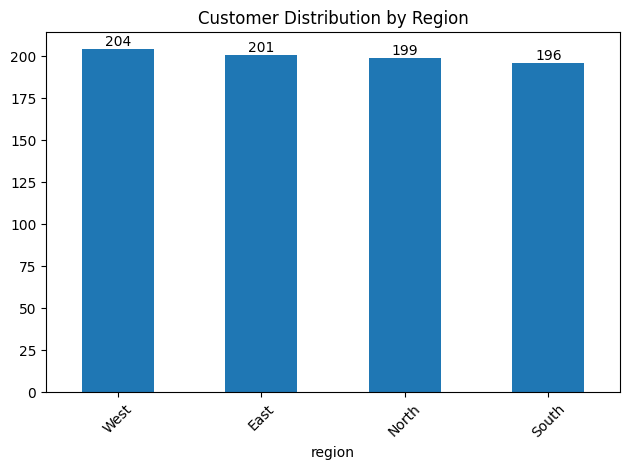

In [388]:
#Customers by Region

customers['region'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by Region")

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

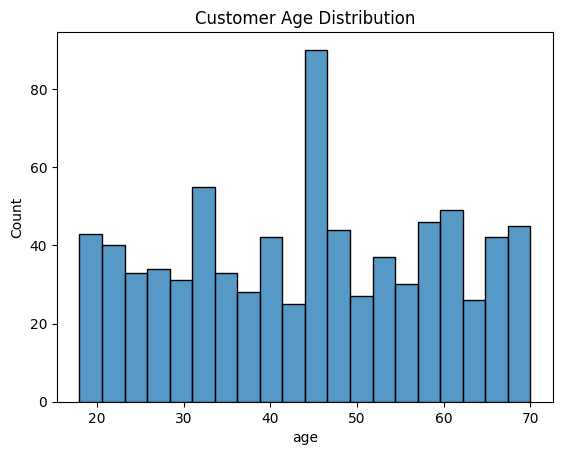

In [389]:
#Age Distribution

sns.histplot(customers['age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

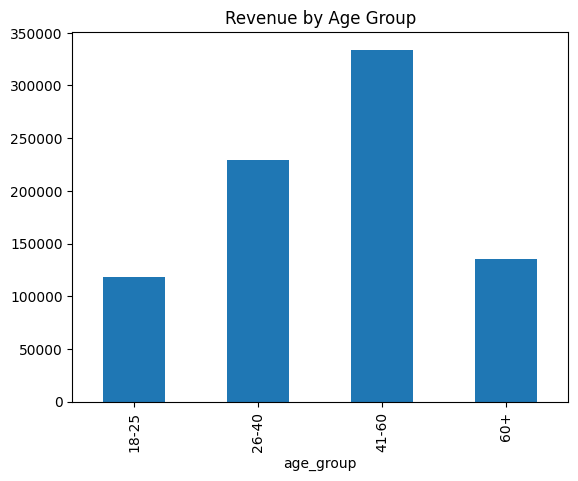

In [390]:
# Revenue by Age Group

sales_customers = salesdata.merge(customers[['customer_id','age_group']], 
                              on='customer_id')

sales_customers.groupby('age_group')['total_amount'].sum().plot(kind='bar')
plt.title("Revenue by Age Group")
plt.show()

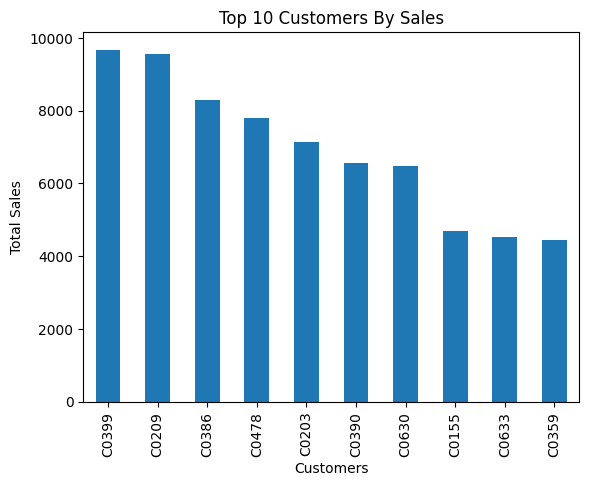

In [391]:
# Top Customers By Sales 
top_customers = salesdata.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False)
top_10_customers = top_customers.head(10)
top_10_customers.plot(kind="bar")
plt.title("Top 10 Customers By Sales")
plt.xlabel("Customers")
plt.ylabel("Total Sales")
plt.show()

## Sales Data EDA

In [28]:
# Merge cost price
sales = salesdata.merge(
    products[['product_id', 'cost_price']],
    on='product_id',
    how='left'
)

# Create profit column
sales['profit'] = (
    (sales['effective_price'] - sales['cost_price'])
    * sales['quantity']
)

# Check
print(sales[['profit']].head())

    profit
0    13.46
1  1571.80
2    47.14
3    -3.04
4   101.11


Text(0, 0.5, 'Sales')

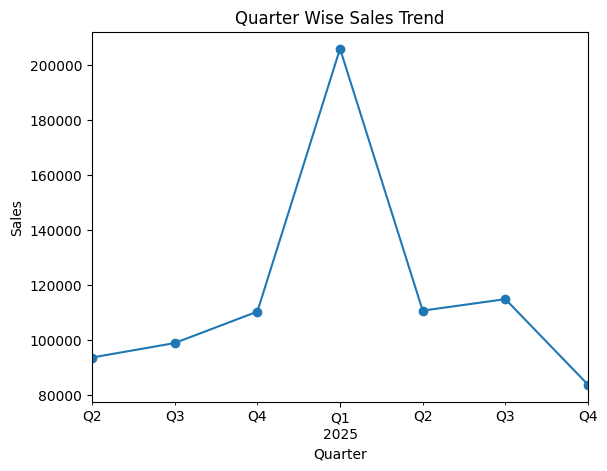

In [392]:
#Quarter Wise Sales Trends
salesdata['order_date'] = pd.to_datetime(salesdata['order_date'],errors='coerce')
salesdata['quarter'] = salesdata['order_date'].dt.to_period('Q')
quarter_wise_sales = salesdata.groupby('quarter')['total_amount'].sum()
quarter_wise_sales.plot(kind ='line',marker='o')
plt.title("Quarter Wise Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")

Text(0, 0.5, 'Sales')

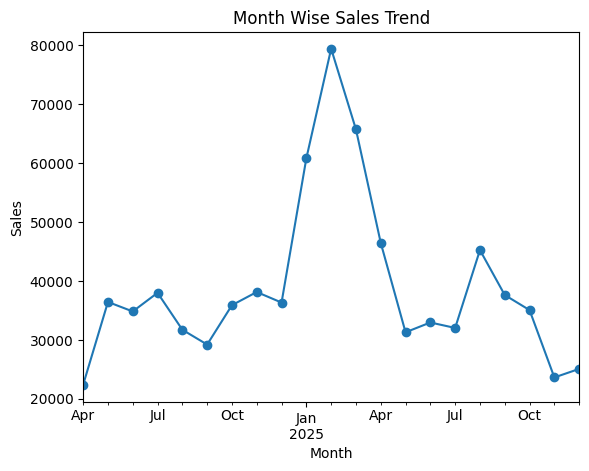

In [393]:
# Month Wise Sales Trends
salesdata['order_date'] = pd.to_datetime(salesdata['order_date'],errors='coerce')
salesdata['month'] = salesdata['order_date'].dt.to_period('M')
month_wise_sales = salesdata.groupby('month')['total_amount'].sum()
month_wise_sales.plot(kind = 'line', marker ='o')
plt.title("Month Wise Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

## Products Data EDA

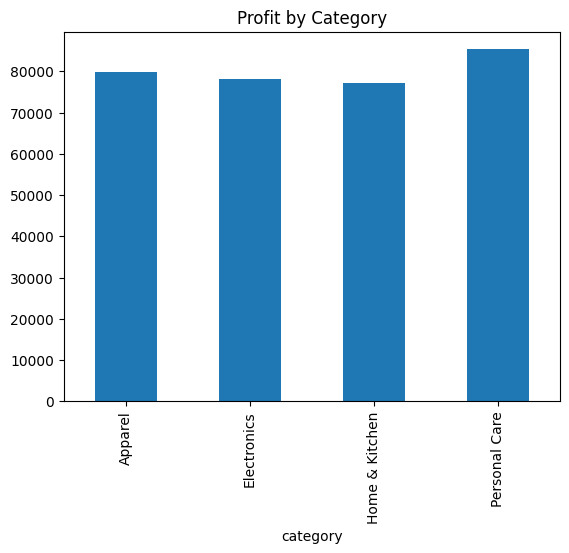

In [394]:
# Profit by Category

sales_products = salesdata.merge(products[['product_id','category','profit_per_unit']],
                             on='product_id')

sales_products['total_profit'] = (
    sales_products['profit_per_unit'] * sales_products['quantity']
)

sales_products.groupby('category')['total_profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

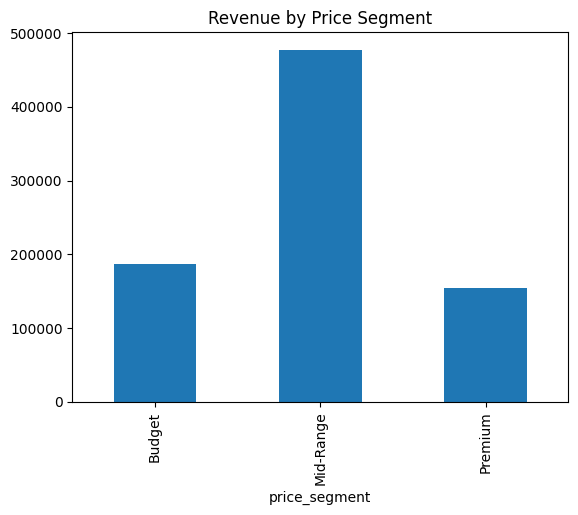

In [395]:
# Revenue by Price Segment

sales_products = sales_products.merge(
    products[['product_id','price_segment']], on='product_id'
)

sales_products.groupby('price_segment')['total_amount'].sum().plot(kind='bar')
plt.title("Revenue by Price Segment")
plt.show()

## Returns Data EDA

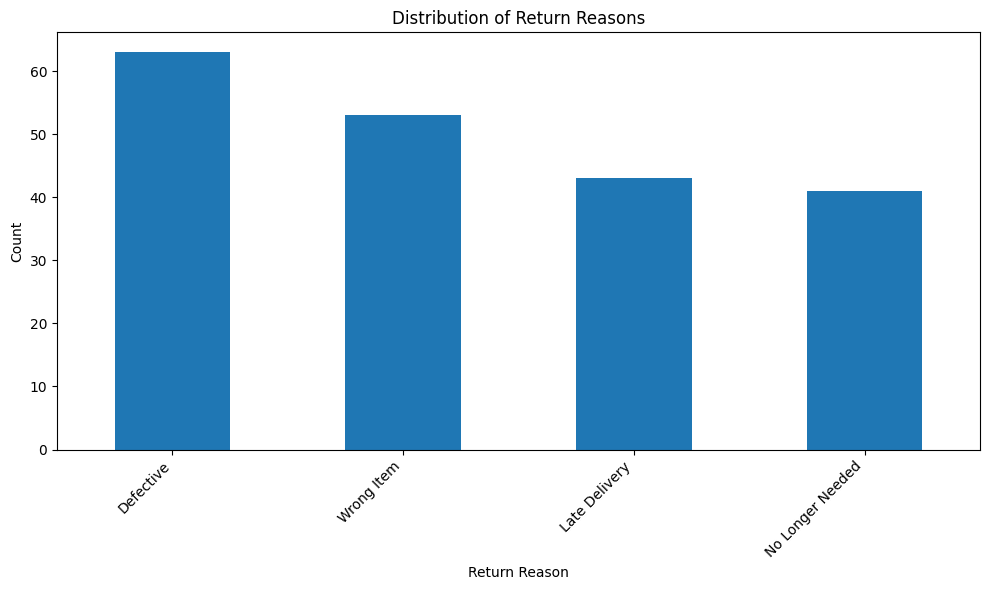

In [398]:
# Distribution of Retrun Regions

reason_counts = returns['return_reason'].value_counts().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
reason_counts.plot(kind='bar')
plt.title('Distribution of Return Reasons')
plt.xlabel('Return Reason')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


## Stores Data EDA

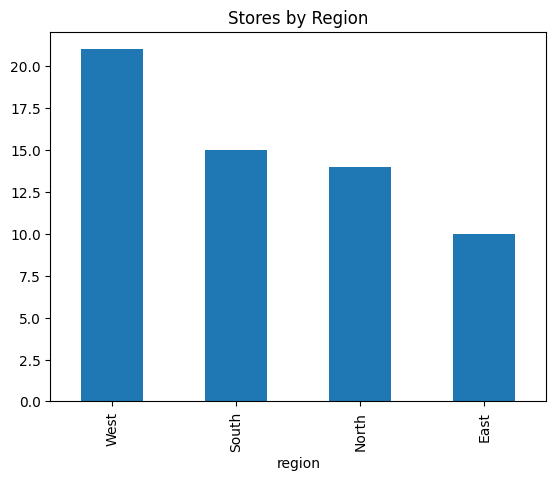

In [379]:
# Store Distribution by Region

stores['region'].value_counts().plot(kind='bar')
plt.title("Stores by Region")
plt.show()